![Health-Informatics: A Python Tutorial](../../Image/chapter-banner.png)


# Module 11:  Clinical Decision Support Systems



**Health Informatics in Python** · Part III: Privacy, Text & Applied Informatics · Module 11 of 16

---



**Clinical Decision Support (CDS)** delivers the right knowledge to the right
person at the right point in the workflow — a screening reminder, a drug-interaction
warning, a risk score. This is where informatics meets the point of care. This
module builds a rule engine over the synthetic EHR, computes a risk score, packages
alerts as **CDS Hooks** cards, and confronts **alert fatigue**.


## Learning objectives

By the end of this module you will be able to:

1. Describe the **"Five Rights"** of CDS and contrast **rule-based** vs **model-driven** support.
2. Represent clinical rules as data/functions and **run them over a cohort**.
3. Compute a simple **risk score** and stratify patients.
4. Package alerts as **CDS Hooks cards** for delivery through a FHIR-based EHR.
5. Measure and mitigate **alert fatigue** through prioritization and suppression.


## Dataset

The synthetic EHR. We build a per-patient **feature view** (age, latest systolic BP,
active conditions, current medications, most recent A1c), the exact input a CDS
rule engine consumes.


In [17]:
# --- Self-contained synthetic EHR generator (identical to Parts I-II) ---
import numpy as np
import pandas as pd

# This function creates a synthetic (fake) Electronic Health Record (EHR) dataset for demonstration and learning purposes.
def make_synthetic_ehr(n_patients=200, seed=42):
    rng = np.random.default_rng(seed)  # Random number generator for reproducibility

    # 1. Generate basic patient demographic info (IDs, names, sex, age, birth year)
    first = ["Ava","Liam","Noah","Mia","Zoe","Omar","Ivan","Sara","Leo","Nina",
             "Ruth","Kai","Yara","Theo","Ida","Sam","Ana","Eli","Rex","Uma"]
    last  = ["Khan","Ortiz","Chen","Diaz","Patel","Ali","Brown","Nash","Reed","Vega",
             "Cole","Frost","Grant","Hale","Iqbal","Jain","Kerr","Lund","Mora","Park"]
    ages  = rng.integers(18, 90, size=n_patients)
    patients = pd.DataFrame({
        "patient_id": [f"P{1000+i}" for i in range(n_patients)],
        "given_name": rng.choice(first, size=n_patients),
        "family_name": rng.choice(last, size=n_patients),
        "sex": rng.choice(["male","female"], size=n_patients, p=[0.49,0.51]),
        "age": ages,
        "birth_year": 2026 - ages,
    })

    # 2. Simulate multiple encounters (visits, admissions) for each patient
    enc_rows, enc_types = [], ["ambulatory","emergency","inpatient","wellness"]
    for pid in patients["patient_id"]:
        for _ in range(rng.integers(1, 5)):  # Each patient has 1 to 4 encounters
            day = rng.integers(0, 365*3)  # Random date over 3 years
            enc_rows.append({
                "encounter_id": f"E{len(enc_rows)+1:05d}",
                "patient_id": pid,
                "encounter_type": rng.choice(enc_types, p=[0.55,0.15,0.10,0.20]),
                "date": (pd.Timestamp("2023-01-01") + pd.Timedelta(days=int(day))).date()
            })
    encounters = pd.DataFrame(enc_rows)

    # 3. Create sets of clinical observations (height, weight, etc.) for each encounter
    obs_defs = [
        ("Body height","cm",150,195),
        ("Body weight","kg",50,110),
        ("Systolic blood pressure","mmHg",100,165),
        ("Heart rate","/min",55,100),
        ("Hemoglobin A1c","%",4.8,9.5)
    ]
    obs_rows = []
    for _, e in encounters.iterrows():
        for name, unit, lo, hi in obs_defs:
            if rng.random() < 0.7:  # About 70% of encounters have each observation
                obs_rows.append({
                    "observation_id": f"O{len(obs_rows)+1:06d}",
                    "encounter_id": e["encounter_id"],
                    "patient_id": e["patient_id"],
                    "observation": name,
                    "value": round(float(rng.uniform(lo,hi)),1),
                    "unit": unit,
                    "date": e["date"]
                })
    observations = pd.DataFrame(obs_rows)

    # 4. Assign random conditions (diagnoses) to each patient
    cond_pool = [
        "Essential hypertension","Type 2 diabetes mellitus","Asthma",
        "Acute bronchitis","Major depressive disorder","Osteoarthritis",
        "Chronic kidney disease","Anemia"
    ]
    cond_rows = []
    for pid in patients["patient_id"]:
        # Each patient can have 0-3 conditions
        for c in rng.choice(cond_pool, size=rng.integers(0,4), replace=False):
            cond_rows.append({
                "condition_id": f"C{len(cond_rows)+1:05d}",
                "patient_id": pid,
                "condition": c
            })
    conditions = pd.DataFrame(cond_rows)

    # 5. Assign random medications to each patient
    med_pool = [
        "Lisinopril","Metformin","Albuterol","Atorvastatin","Sertraline",
        "Amoxicillin","Ibuprofen","Hydrochlorothiazide"
    ]
    med_rows = []
    for pid in patients["patient_id"]:
        # Each patient can have 0-3 medications
        for m in rng.choice(med_pool, size=rng.integers(0,4), replace=False):
            med_rows.append({
                "medication_id": f"M{len(med_rows)+1:05d}",
                "patient_id": pid,
                "medication": m
            })
    medications = pd.DataFrame(med_rows)

    # 6. Return all pieces as a dictionary of DataFrames
    return {
        "patients": patients,
        "encounters": encounters,
        "observations": observations,
        "conditions": conditions,
        "medications": medications
    }

# Create an EHR dataset and print table sizes
ehr = make_synthetic_ehr()
print("Tables:", ", ".join(f"{k} ({len(v)})" for k,v in ehr.items()))


Tables: patients (200), encounters (511), observations (1804), conditions (304), medications (276)


## 11.1 The Five Rights of CDS

Effective Clinical Decision Support (CDS) delivers interventions by closely adhering to the "Five Rights" framework:

1. **The right information:** Relevant, evidence-based guidance or data, such as clinical recommendations or alerts about abnormal values.
2. **To the right person:** Presented to the appropriate member of the care team—this could be a physician, nurse, pharmacist, or even the patient.
3. **In the right format:** The CDS can be shown as an alert, order set, documentation template, reference information, or other context-sensitive format appropriate to the workflow.
4. **Through the right channel:** Delivered within the system or application where the recipient is working—most commonly within the EHR, but sometimes via mobile apps, pagers, or verbal alerts.
5. **At the right point in workflow:** Provided at a time when it can make a difference, such as when entering orders, reviewing results, or during a clinical encounter.

There are two major approaches to CDS:

- **Rule-based CDS:** Hard-coded, explicit logic that implements clinical guidelines as "if-then" statements (e.g., "If the patient has diabetes and no recent A1c lab, remind the provider to order one"). These are easy to audit and understand, but can be brittle and require maintenance as evidence evolves.
- **Model-driven (AI-based) CDS:** Uses statistical or machine learning models trained on data to make predictions or recommendations (e.g. risk scores for sepsis, readmission). These can capture complex relationships but are less transparent and harder to trace.

In practice, most real CDS systems use a combination of both approaches: models for prediction, and rules for enforceability, safety, and auditability. Rule-based CDS is still dominant in many settings due to its simplicity and transparency for both developers and clinicians.


## 11.2 Build the per-patient feature view

In preparation for clinical decision support, we need a consolidated "feature view" for each patient.
This per-patient feature view should summarize key data elements relevant to CDS rules:
- Demographics (e.g., age, sex)
- Most recent results for important labs or observations
- A set of all active conditions
- A set of all current medications
This structure makes it easy to apply rules and generate alerts on a patient-by-patient basis.

In [18]:
import pandas as pd, numpy as np

# Pull out patient and observation tables
patients, obs = ehr["patients"], ehr["observations"].copy()

# Ensure 'date' column in observations is in datetime format
obs["date"] = pd.to_datetime(obs["date"])

# Helper function to get each patient's most recent value for a specific observation
def latest(observation):
    sub = obs[obs["observation"]==observation].sort_values("date")
    return sub.groupby("patient_id")["value"].last()

# Start building the per-patient feature dataframe using age and sex, indexed by patient_id
feat = patients.set_index("patient_id")[["age","sex"]].copy()

# Add latest systolic BP value for each patient
feat["latest_sbp"] = latest("Systolic blood pressure")

# Add latest Hemoglobin A1c for each patient
feat["latest_a1c"] = latest("Hemoglobin A1c")

# Add set of conditions for each patient (empty set if none)
feat["conditions"] = (
    ehr["conditions"]
    .groupby("patient_id")["condition"]
    .apply(set)
    .reindex(feat.index)
    .apply(lambda s: s if isinstance(s, set) else set())
)

# Add set of current medications for each patient (empty set if none)
feat["medications"] = (
    ehr["medications"]
    .groupby("patient_id")["medication"]
    .apply(set)
    .reindex(feat.index)
    .apply(lambda s: s if isinstance(s, set) else set())
)

print("Per-patient CDS feature view (first 5):")
feat.head()

Per-patient CDS feature view (first 5):


,age,sex,latest_sbp,latest_a1c,conditions,medications
patient_id,,,,,,
P1000,24,female,158.7,6.7,"{Anemia, Osteoarthritis}","{Lisinopril, Hydrochlorothiazide, Sertraline}"
P1001,73,male,112.3,8.9,{Acute bronchitis},{}
P1002,65,female,NaN,NaN,"{Type 2 diabetes mellitus, Anemia, Asthma}","{Ibuprofen, Hydrochlorothiazide, Sertraline}"
P1003,49,female,104.1,5.2,"{Major depressive disorder, Essential hyperten...",{}
P1004,49,female,160.9,7.2,{},"{Hydrochlorothiazide, Amoxicillin, Albuterol}"


## 11.3 A rule engine

Each clinical decision support rule is defined as a Python function that takes
a single patient's feature row (from the feat DataFrame) as input and returns
either a dictionary describing an alert (if the rule is triggered for that patient)
or None (if not triggered). This alert dictionary typically includes fields such as
'rule' (a short identifier for the rule), 'severity', and a human-readable message.

By representing all rules in this consistent, functional style, we keep the rules isolated
from the rule engine logic itself. This makes the rule system modular and extensible:
to add a new rule, you simply implement a new function following this pattern and include it
in the RULES list. The rule runner code does not need to change, regardless of how many rules
exist or what they evaluate.


In [19]:
# --- Clinical Decision Support Rules and Rule Engine ---

# Rule 1: Uncontrolled Hypertension
# Triggers if a patient has recorded "Essential hypertension" and their latest systolic blood pressure (SBP) is 140 mmHg or higher.
def rule_uncontrolled_htn(f):
    if "Essential hypertension" in f["conditions"] and f["latest_sbp"] and f["latest_sbp"]>=140:
        return dict(
            rule="uncontrolled_htn",
            severity="warning",
            msg=f"BP {f['latest_sbp']:.0f} mmHg with hypertension — consider intensifying therapy."
        )

# Rule 2: Diabetes but No Recent HbA1c
# Triggers if a patient has "Type 2 diabetes mellitus" but no hemoglobin A1c value on record.
def rule_diabetes_no_a1c(f):
    if "Type 2 diabetes mellitus" in f["conditions"] and pd.isna(f["latest_a1c"]):
        return dict(
            rule="diabetes_no_a1c",
            severity="info",
            msg="Diabetic patient with no A1c on record — order HbA1c."
        )

# Rule 3: NSAID Prescribed to CKD Patient
# Triggers if a patient with chronic kidney disease has been prescribed ibuprofen (an NSAID), which is contraindicated.
def rule_nsaid_ckd(f):
    if "Ibuprofen" in f["medications"] and "Chronic kidney disease" in f["conditions"]:
        return dict(
            rule="nsaid_ckd",
            severity="critical",
            msg="NSAID (ibuprofen) prescribed with CKD — contraindicated; review."
        )

# Rule 4: Statin Not Prescribed for At-Risk Diabetic
# Triggers if a diabetic patient age 40 or older is not receiving a statin (here, Atorvastatin).
def rule_statin_gap(f):
    if ("Type 2 diabetes mellitus" in f["conditions"]
        and f["age"]>=40
        and "Atorvastatin" not in f["medications"]):
        return dict(
            rule="statin_gap",
            severity="info",
            msg="Diabetic >=40 not on a statin — consider statin therapy."
        )

# List of all rule functions to evaluate for each patient.
RULES = [
    rule_uncontrolled_htn,
    rule_diabetes_no_a1c,
    rule_nsaid_ckd,
    rule_statin_gap
]

# Rule engine: Run all rules for each patient feature row.
# Returns a dataframe of alerts, each corresponding to a rule that fired for a patient.
def run_rules(feat):
    alerts = []
    for pid, f in feat.iterrows():      # Iterate over all patients by patient_id
        for rule in RULES:              # For each rule...
            hit = rule(f)               # ...evaluate rule for this patient's features
            if hit:                     # If rule fires (returns a dict)...
                alerts.append({"patient_id": pid, **hit})  # ...record the alert
    return pd.DataFrame(alerts)          # Combine all alerts into a DataFrame

# Run all rules across the feature table and display summary statistics about alerts.
alerts = run_rules(feat)
print(f"Total alerts fired: {len(alerts)} across {alerts['patient_id'].nunique()} patients")
print(alerts["rule"].value_counts())

Total alerts fired: 50 across 45 patients
rule
statin_gap          24
uncontrolled_htn    12
diabetes_no_a1c      7
nsaid_ckd            7
Name: count, dtype: int64


### Milestone 1 - alerts for one patient

Here we will display the alerts generated by the rule engine for a single patient.
We will select the first patient ID from the alerts DataFrame and print out each alert 
for that patient, including its severity and message, to illustrate the personalized
decision support being delivered.

In [20]:
# Select the first patient in the alerts DataFrame to use as an example
example_pid = alerts["patient_id"].iloc[0]
print(f"Alerts for {example_pid}:")
# Iterate over all alerts for this patient and print each alert's severity and message
for _, a in alerts[alerts["patient_id"]==example_pid].iterrows():
    print(f"  [{a['severity'].upper():8s}] {a['msg']}")

Alerts for P1002:
  [INFO    ] Diabetic patient with no A1c on record — order HbA1c.
  [INFO    ] Diabetic >=40 not on a statin — consider statin therapy.


## 11.4 A risk score

In addition to providing alerts as simple yes/no (boolean) rules, Clinical Decision Support (CDS) systems also frequently offer a **risk score** for a given clinical problem. 
A risk score quantifies a patient's likelihood of a future adverse outcome (here, for cardiovascular disease) in a point-based, interpretable way. 
The following example implements a straightforward cardiovascular risk point system for educational purposes. 
This system assigns points to a patient based on their age group, elevated systolic blood pressure, and/or specific chronic conditions (such as diabetes, hypertension, or chronic kidney disease). 
The higher the total points, the greater the cardiovascular risk. This simple score is not a validated medical tool, but illustrates the logic that real world CDS uses to stratify risk and personalize care recommendations.


In [21]:
# The following function and code implement a simple, interpretable cardiovascular risk scoring system:

def cv_risk_points(f):
    """
    Compute a cardiovascular risk score for a patient.
    
    Parameters:
      f (pd.Series): Patient features/row.
      
    Returns:
      int: Total risk points for this patient.
    """
    pts = 0
    # Age points: 2 points if 65 or older, 1 point if between 50 and 64, otherwise 0.
    pts += {True:2, False:0}[f["age"]>=65] + {True:1, False:0}[50<=f["age"]<65]
    # Systolic blood pressure: 2 points if latest_sbp is 140 or higher.
    if f["latest_sbp"] and f["latest_sbp"]>=140: 
        pts += 2
    # Chronic conditions:
    # 2 points if patient has Type 2 diabetes mellitus.
    pts += int("Type 2 diabetes mellitus" in f["conditions"]) * 2
    # 1 point if patient has essential hypertension.
    pts += int("Essential hypertension" in f["conditions"]) * 1
    # 2 points if patient has chronic kidney disease.
    pts += int("Chronic kidney disease" in f["conditions"]) * 2
    # Return the total risk points
    return pts

# Apply the risk point calculation for every patient in feat DataFrame.
feat["cv_points"] = feat.apply(cv_risk_points, axis=1)

# Stratify patients into risk bands based on their total points:
# -1 to 1 = "low", 2 to 3 = "moderate", 4+ = "high".
feat["cv_band"] = pd.cut(
    feat["cv_points"], 
    bins=[-1,1,3,99], 
    labels=["low","moderate","high"]
)

print("Risk stratification:")
print(feat["cv_band"].value_counts())  # Show how many patients fall into each risk band

print("\nHighest-risk patients:")
# Show top 5 patients with the highest risk scores, including age, latest SBP, total points, and risk band.
print(
    feat
    .sort_values("cv_points", ascending=False)[["age","latest_sbp","cv_points","cv_band"]]
    .head()
    .to_string()
)

Risk stratification:
cv_band
moderate    92
high        66
low         42
Name: count, dtype: int64

Highest-risk patients:
            age  latest_sbp  cv_points cv_band
patient_id                                    
P1127        73       152.0          8    high
P1183        68       150.4          8    high
P1165        76       157.2          7    high
P1125        58       158.7          7    high
P1144        89       134.9          7    high


## 11.5 Delivering alerts as CDS Hooks cards

**CDS Hooks** is a widely adopted standard for delivering clinical decision support within an Electronic Health Record (EHR) system. 
When a specific workflow event occurs in the EHR—such as a clinician opening a patient's chart (`patient-view`)—the EHR triggers
a request to an external CDS (Clinical Decision Support) service. The CDS service evaluates the latest patient data and context,
and responds with a set of **cards** containing decision support information to be displayed to the clinician.

Each card is a structured message that typically includes:
- `summary`: a concise headline summarizing the alert or advice (max 140 characters, shown prominently)
- `indicator`: the severity level of the card—either `"info"`, `"warning"`, or `"critical"`—which influences the EHR's visual display
- `detail`: a longer explanation providing more context and justification for the recommendation
- `source`: attribution information for the rule or CDS application generating the card (e.g., "Source: Medication Safety CDS v1.0")
- `suggestions` (optional): actionable buttons or choices that the clinician may execute directly from the card, such as ordering a lab test,
  adjusting a medication, or simply documenting acknowledgment.

CDS Hooks ensures this exchange is standardized, so that EHRs and external CDS services can interoperate reliably across settings and vendors.


In [22]:
import json

# This dictionary maps human-readable severity labels to the CDS Hooks "indicator" levels
INDICATOR = {"info":"info","warning":"warning","critical":"critical"}

def to_cds_card(alert):
    """
    Converts a single alert (row from DataFrame) into a CDS Hooks card dictionary.
    - summary: Up to 140 characters summarizing the message.
    - indicator: Severity ("info", "warning", "critical") for visual emphasis.
    - detail: Full message to show more context.
    - source: Label indicating which rule generated the card.
    - suggestions: Button for the clinician to acknowledge/document the alert.
    """
    return {
        "summary": alert["msg"][:140],  # Truncate to 140 chars for the headline
        "indicator": INDICATOR[alert["severity"]],  # Standardized severity value
        "detail": alert["msg"],  # Longer explanation, full message
        "source": {"label": "HealthInformatics CDS (rule: %s)" % alert["rule"]},  # Source for audit/attribution
        "suggestions": [{"label": "Acknowledge and document"}],  # Optional action button
    }

def cds_response_for(pid):
    """
    For a given patient id (pid), return a CDS Hooks-compliant response.
    This looks up all alerts for the patient and packages them as cards.
    {
        "cards": [ ...list of CDS cards for that patient... ]
    }
    """
    # Select only alerts for the specified patient
    pid_alerts = alerts[alerts["patient_id"] == pid]
    # Convert each alert row into a CDS card dictionary
    return {"cards": [to_cds_card(a) for _, a in pid_alerts.iterrows()]}

# Create a sample CDS Hooks response for a sample patient and print as pretty-printed JSON
sample = cds_response_for(example_pid)
print(json.dumps(sample, indent=2))

{
  "cards": [
    {
      "summary": "Diabetic patient with no A1c on record \u2014 order HbA1c.",
      "indicator": "info",
      "detail": "Diabetic patient with no A1c on record \u2014 order HbA1c.",
      "source": {
        "label": "HealthInformatics CDS (rule: diabetes_no_a1c)"
      },
      "suggestions": [
        {
          "label": "Acknowledge and document"
        }
      ]
    },
    {
      "summary": "Diabetic >=40 not on a statin \u2014 consider statin therapy.",
      "indicator": "info",
      "detail": "Diabetic >=40 not on a statin \u2014 consider statin therapy.",
      "source": {
        "label": "HealthInformatics CDS (rule: statin_gap)"
      },
      "suggestions": [
        {
          "label": "Acknowledge and document"
        }
      ]
    }
  ]
}


### Milestone 2 - this is what the EHR renders at the point of care
The following represents exactly what the clinician sees in the EHR interface at the moment of care—how clinical alerts, recommendations, and supporting information are displayed to guide decision-making in real time.


In [23]:
# For each card (alert) in the sample CDS Hooks response, display a summary
for card in sample["cards"]:
    # Assign an icon based on the card's indicator severity
    icon = {"info":"ℹ️", "warning":"⚠️", "critical":"⛔"}[card["indicator"]]
    # Print the icon, severity, and summary of the alert
    print(f"{icon} [{card['indicator'].upper()}] {card['summary']}")
    # Print the source rule that generated the alert for reference
    print(f"    source: {card['source']['label']}\n")

ℹ️ [INFO] Diabetic patient with no A1c on record — order HbA1c.
    source: HealthInformatics CDS (rule: diabetes_no_a1c)

ℹ️ [INFO] Diabetic >=40 not on a statin — consider statin therapy.
    source: HealthInformatics CDS (rule: statin_gap)



## 11.6 Alert fatigue - the central usability risk

The most common failure of Clinical Decision Support (CDS) systems is known as **alert fatigue**. 
This occurs when clinicians are repeatedly exposed to a high volume of low-importance alerts—such as minor warnings or informational messages—which leads them to become desensitized. 
As a result, they may begin to ignore not just the low-value alerts, but also truly critical warnings that require immediate attention, potentially compromising patient safety.
In practice, this is reflected by override rates (alerts ignored or dismissed by clinicians) sometimes exceeding 90% in CDS systems that are not carefully optimized.
Effective CDS design uses two main strategies to address alert fatigue:
  1. **Prioritizing by severity**: Ensuring that only the most clinically important and relevant alerts are highlighted prominently, while less urgent alerts are shown with lower priority.
  2. **Suppressing low-value alerts**: Filtering out alerts that are unlikely to inform or change clinical decision-making, so as to minimize unnecessary interruptions for clinicians.


Alert burden — mean 1.11, max 2 alerts/patient
Alerts before: 50  ->  after prioritization: 50 (0% reduction)


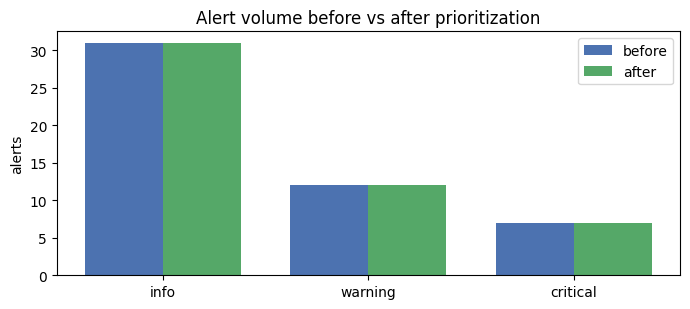

In [24]:
import matplotlib.pyplot as plt

# Calculate number of alerts per patient in original alerts DataFrame
burden = alerts.groupby("patient_id").size()
print(f"Alert burden — mean {burden.mean():.2f}, max {burden.max()} alerts/patient")

# Define a suppression/prioritization policy:
# For each patient, if there is at least one critical alert,
# suppress (i.e., remove) their informational ("info") alerts to prevent overload.
def prioritize(alerts):
    keep = []  # This will collect the alerts to keep
    for pid, grp in alerts.groupby("patient_id"):
        # Check if the group for this patient has any critical alerts
        has_critical = (grp["severity"] == "critical").any()
        for _, a in grp.iterrows():
            # If any alert for this patient is critical, skip their "info" alerts
            if has_critical and a["severity"] == "info":
                continue  # Skip "info" alerts due to higher-severity present
            keep.append(a)  # Otherwise, keep the alert
    # Return all retained alerts as a new DataFrame
    return pd.DataFrame(keep)

# Apply prioritization strategy to alerts
filtered = prioritize(alerts)
print(f"Alerts before: {len(alerts)}  ->  after prioritization: {len(filtered)} "
      f"({100*(1-len(filtered)/len(alerts)):.0f}% reduction)")

# Plot the total count of each severity level before and after prioritization
fig, ax = plt.subplots(figsize=(7, 3.2))
order = ["info", "warning", "critical"]
before = alerts["severity"].value_counts().reindex(order).fillna(0)
after = filtered["severity"].value_counts().reindex(order).fillna(0)
x = np.arange(len(order))  # X locations for severity labels
w = 0.38  # Bar width

# Plot count before prioritization
ax.bar(x - w / 2, before, w, label="before", color="#4C72B0")
# Plot count after prioritization
ax.bar(x + w / 2, after, w, label="after", color="#55A868")
# Set x-axis labels and legend
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("alerts")
ax.legend()
ax.set_title("Alert volume before vs after prioritization")
plt.tight_layout()
plt.show()

## Exercises

1. Add a **drug–drug interaction** rule (e.g. two antihypertensives) and confirm it
   flows through to CDS Hooks cards.
2. Make severity **actionable**: attach a `suggestions` action to the `nsaid_ckd`
   card that proposes discontinuing the NSAID.
3. Replace the risk points with a **logistic risk model** trained on the features
   (bridge to the model-driven CDS of the Clinical AI series) and compare which
   patients each approach flags.



## Key takeaways

- CDS is governed by the **Five Rights**; **rule-based** and **model-driven**
  support complement each other.
- A clean design makes each **rule a function**, so the engine scales without churn.
- **CDS Hooks cards** (summary/indicator/detail/source/suggestions) are the standard
  delivery format inside FHIR-based EHRs.
- **Alert fatigue** is the defining usability failure; **prioritization and
  suppression** are essential, not optional.



---
*End of Part III — Privacy, Text & Applied Informatics. Next: Part IV — Advanced Topics.*
